# CONSUMER PURCHASE ANALYSIS
### PurchATIL
##### GROUP 4: JOE (ALPHINTINO), TJITSKE (ELIZABETH), KEATON, INGER

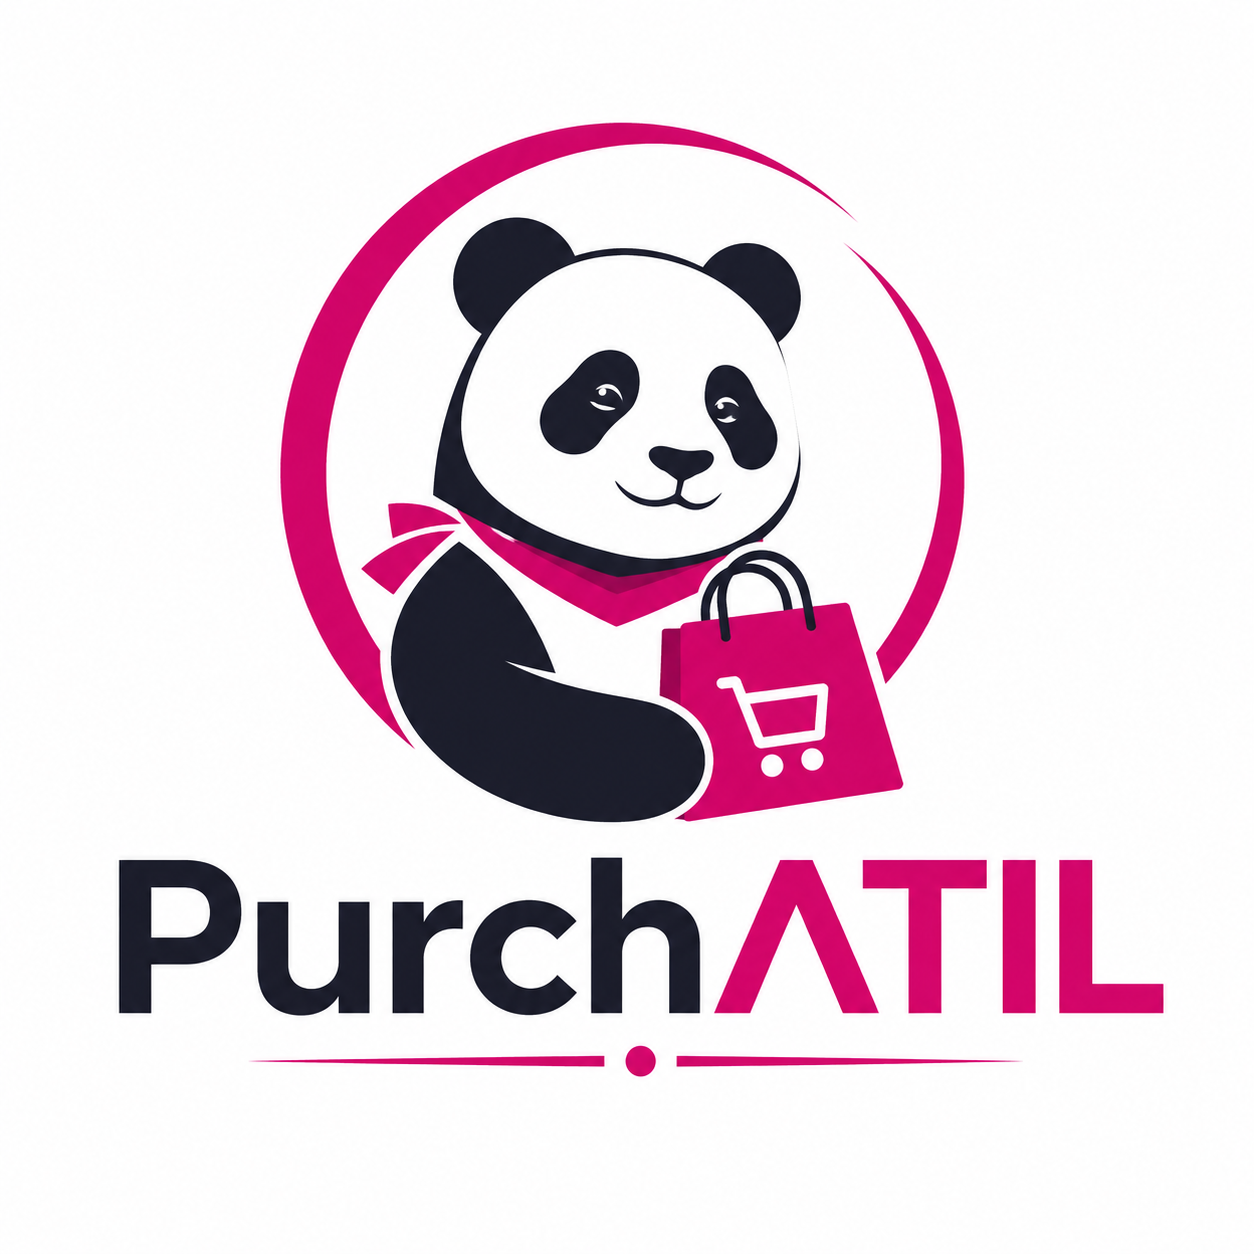

In [ ]:
# Import all libraries

import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn import metrics

In [ ]:
# Import data into dataframe
df = pd.read_excel('E_Commerce.xlsx')
df.head()

,User ID,Gender,Age,EstimatedSalary,Education_Livel,Region,Employment_type,Product_Category,Time_Spent,Num_of_children,Purch_Attention,Purchased
0,15792008,Male,30,15000.0,0.0,North,Permanent,Clothing,15.0,2.0,PA_01,0
1,15809823,Male,26,15000.0,0.0,South,Permanent,Accessories,10.0,0.0,PA_01,0
2,15679651,Female,26,15000.0,2.0,East,Unemployed,Clothing,13.0,1.0,PA_01,0
3,15610140,Female,31,15000.0,1.0,West,Contract,Accessories,16.0,0.0,PA_01,0
4,15573452,Female,21,16000.0,2.0,South,Permanent,Clothing,9.0,1.0,PA_01,0


In [ ]:
# Upload csv file with google colab
#from google.colab import files
#uploaded = files.upload()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User ID            400 non-null    int64  
 1   Gender             397 non-null    object 
 2   Age                400 non-null    int64  
 3   EstimatedSalary    396 non-null    float64
 4   Education_Livel    396 non-null    float64
 5   Region             394 non-null    object 
 6   Employment_type    394 non-null    object 
 7   Product_Category   387 non-null    object 
 8   Time_Spent         398 non-null    float64
 9   Num_of_children    396 non-null    float64
 10  Purch_Attention    400 non-null    object 
 11  Purchased          400 non-null    int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 37.6+ KB


In [ ]:
df.describe()

,User ID,Age,EstimatedSalary,Education_Livel,Time_Spent,Num_of_children,Purchased
count,4.000000e+02,400.000000,396.000000,396.000000,398.000000,396.000000,400.000000
mean,1.569154e+07,37.655000,69729.797980,2.378788,25.188442,1.787879,0.357500
std,7.165832e+04,10.482877,34268.932248,1.538684,15.963187,1.058040,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000,5.000000,0.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,1.000000,13.000000,1.000000,0.000000
50%,1.569434e+07,37.000000,68500.000000,2.000000,21.000000,2.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,3.000000,33.750000,3.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,5.000000,65.000000,4.000000,1.000000


In [ ]:
# Check for duplicate rows

duplicates = df.duplicated()

# Count duplicates
print("Number of duplicate rows:", duplicates.sum())

# Display duplicate rows
print(df[df.duplicated()])

Number of duplicate rows: 0
Empty DataFrame
Columns: [User ID, Gender, Age, EstimatedSalary, Education_Livel, Region, Employment_type, Product_Category , Time_Spent, Num_of_children, Purch_Attention, Purchased]
Index: []


In [ ]:
# After finding no duplicated values checking for missing values
df.isnull().sum()

,0
User ID,0
Gender,3
Age,0
EstimatedSalary,4
Education_Livel,4
Region,6
Employment_type,6
Product_Category,13
Time_Spent,2
Num_of_children,4


***Fixing missing values.***

With having only 400 rows we went with imputation rather then deleting rows with missing values.

In [ ]:
# Fill missing numerical values with median (Median over Mean to be less effected by high values as our max on multiple categories were above the 1.5 * IQR)
df['EstimatedSalary'] = df['EstimatedSalary'].fillna(df['EstimatedSalary'].median())
df['Time_Spent'] = df['Time_Spent'].fillna(df['Time_Spent'].median())
df['Num_of_children'] = df['Num_of_children'].fillna(df['Num_of_children'].median())

In [ ]:
# Fill missing categorical values with the mode
print('Current DataFrame columns:', df.columns.tolist())
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Education_Livel'] = df['Education_Livel'].fillna(df['Education_Livel'].mode()[0])
df['Region'] = df['Region'].fillna(df['Region'].mode()[0])
df['Employment_type'] = df['Employment_type'].fillna(df['Employment_type'].mode()[0])

Current DataFrame columns: ['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Education_Livel', 'Region', 'Employment_type', 'Product_Category ', 'Time_Spent', 'Num_of_children', 'Purch_Attention', 'Purchased']


In [ ]:
# Ensure all missing values are gone
df.isnull().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Education_Livel,0
Region,0
Employment_type,0
Product_Category,13
Time_Spent,0
Num_of_children,0


In [ ]:
# REMOVE USER ID column as it does not help predict anything
df = df.drop('User ID', axis=1)
df

,Gender,Age,EstimatedSalary,Education_Livel,Region,Employment_type,Product_Category,Time_Spent,Num_of_children,Purch_Attention,Purchased
0,Male,30,15000.0,0.0,North,Permanent,Clothing,15.0,2.0,PA_01,0
1,Male,26,15000.0,0.0,South,Permanent,Accessories,10.0,0.0,PA_01,0
2,Female,26,15000.0,2.0,East,Unemployed,Clothing,13.0,1.0,PA_01,0
3,Female,31,15000.0,1.0,West,Contract,Accessories,16.0,0.0,PA_01,0
4,Female,21,16000.0,2.0,South,Permanent,Clothing,9.0,1.0,PA_01,0
...,...,...,...,...,...,...,...,...,...,...,...
395,Male,29,148000.0,2.0,South,Contract,Clothing,57.0,4.0,PA_04,1
396,Female,33,149000.0,5.0,North,Permanent,Electronics,15.0,4.0,PA_04,1
397,Male,42,149000.0,3.0,East,Self-employed,Electronics,15.0,2.0,PA_04,1
398,Female,32,150000.0,2.0,West,Unemployed,Accessories,25.0,1.0,PA_04,1


In [ ]:
# Map 'Purch_Attention' to numerical values to allow regression
purchase_attention_mapping = {'PA_01': 1, 'PA_02': 2, 'PA_03': 3, 'PA_04': 4}
df['Purch_Attention_Numerical'] = df['Purch_Attention'].map(purchase_attention_mapping)


# Show new column
display(df[['Purch_Attention', 'Purch_Attention_Numerical']])

,Purch_Attention,Purch_Attention_Numerical
0,PA_01,1
1,PA_01,1
2,PA_01,1
3,PA_01,1
4,PA_01,1
...,...,...
395,PA_04,4
396,PA_04,4
397,PA_04,4
398,PA_04,4


In [ ]:
# Change product category column into numerical and dummy.
# Get unique values in 'Product_Category '
unique_product_categories = df['Product_Category '].unique()
print(f"Unique Product Categories: {unique_product_categories}")

# Perform one-hot encoding on 'Product_Category '
product_category_dummies = pd.get_dummies(df['Product_Category '], prefix='Product_Category')


# Concatenate the new dummy variables with the original DataFrame
df = pd.concat([df, product_category_dummies], axis=1)


# Drop the original 'Product_Category ' column
df = df.drop('Product_Category ', axis=1)


# Display the head of the DataFrame to verify the new columns
display(df.head())

Unique Product Categories: ['Clothing' 'Accessories' 'Electronics' nan]


,Gender,Age,EstimatedSalary,Education_Livel,Region,Employment_type,Time_Spent,Num_of_children,Purch_Attention,Purchased,Purch_Attention_Numerical,Product_Category_Accessories,Product_Category_Clothing,Product_Category_Electronics
0,Male,30,15000.0,0.0,North,Permanent,15.0,2.0,PA_01,0,1,False,True,False
1,Male,26,15000.0,0.0,South,Permanent,10.0,0.0,PA_01,0,1,True,False,False
2,Female,26,15000.0,2.0,East,Unemployed,13.0,1.0,PA_01,0,1,False,True,False
3,Female,31,15000.0,1.0,West,Contract,16.0,0.0,PA_01,0,1,True,False,False
4,Female,21,16000.0,2.0,South,Permanent,9.0,1.0,PA_01,0,1,False,True,False


In [ ]:
# Convert 'Gender' to numerical (binary)
df['Gender_Numerical'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Display the head of the new column to verify
display(df[['Gender', 'Gender_Numerical']].head())
display(df['Gender_Numerical'].value_counts())

,Gender,Gender_Numerical
0,Male,0
1,Male,0
2,Female,1
3,Female,1
4,Female,1


,count
Gender_Numerical,
1,205
0,195


In [ ]:
# Select numerical columns for correlation matrix
# Now including 'Gender_Numerical', 'Purch_Attention_Numerical', and one-hot encoded product categories
numerical_cols = ['Age', 'EstimatedSalary', 'Education_Livel', 'Time_Spent', 'Num_of_children', 'Gender_Numerical', 'Purch_Attention_Numerical', 'Purchased', 'Product_Category_Accessories', 'Product_Category_Clothing', 'Product_Category_Electronics']
correlation_matrix = df[numerical_cols].corr()


# Display the correlation matrix
display(correlation_matrix)

,Age,EstimatedSalary,Education_Livel,Time_Spent,Num_of_children,Gender_Numerical,Purch_Attention_Numerical,Purchased,Product_Category_Accessories,Product_Category_Clothing,Product_Category_Electronics
Age,1.000000,0.155389,0.017290,0.454915,0.185060,0.065793,0.465553,0.622454,0.053731,0.022886,-0.032744
EstimatedSalary,0.155389,1.000000,0.574595,0.350322,0.412798,0.060057,0.717447,0.362631,0.013403,0.011805,0.041205
Education_Livel,0.017290,0.574595,1.000000,0.193281,0.275887,0.003679,0.478344,0.192266,0.011228,0.017025,0.013470
Time_Spent,0.454915,0.350322,0.193281,1.000000,0.291605,0.054607,0.645194,0.728389,0.019833,0.060050,-0.028644
Num_of_children,0.185060,0.412798,0.275887,0.291605,1.000000,0.024018,0.449678,0.307687,-0.007473,0.045769,-0.015085
Gender_Numerical,0.065793,0.060057,0.003679,0.054607,0.024018,1.000000,0.040256,0.038743,-0.010582,0.027692,-0.040187
Purch_Attention_Numerical,0.465553,0.717447,0.478344,0.645194,0.449678,0.040256,1.000000,0.798370,-0.016669,0.030104,0.059483
Purchased,0.622454,0.362631,0.192266,0.728389,0.307687,0.038743,0.798370,1.000000,-0.020955,0.032199,0.039333
Product_Category_Accessories,0.053731,0.013403,0.011228,0.019833,-0.007473,-0.010582,-0.016669,-0.020955,1.000000,-0.415926,-0.503380
Product_Category_Clothing,0.022886,0.011805,0.017025,0.060050,0.045769,0.027692,0.030104,0.032199,-0.415926,1.000000,-0.506422


Now that 'Gender' has been converted to a numerical format, we can include it in the correlation matrix.

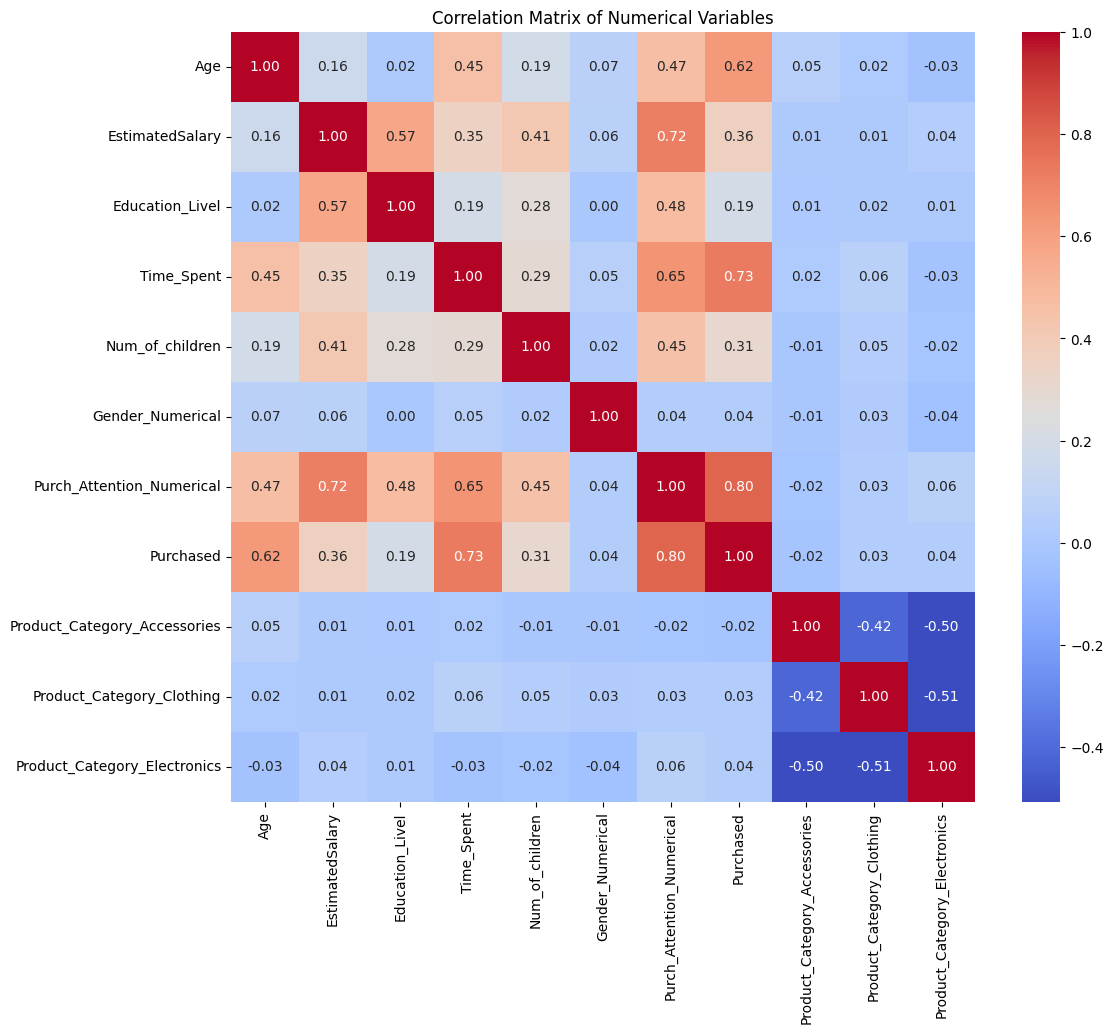

In [ ]:
# Make the previous correlation matrix into a heat map to visually see correlation
plt.figure(figsize=(12, 10)) # Increased figure size for more variables
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

In [ ]:
# Extract correlations with 'Purchased'
purchased_correlations = correlation_matrix['Purchased'].drop('Purchased')


# Sort by absolute correlation value to identify strongest predictors
sorted_correlations = purchased_correlations.abs().sort_values(ascending=False)


print("\nCorrelations with 'Purchased' (sorted by absolute value):\n")
print(sorted_correlations)


Correlations with 'Purchased' (sorted by absolute value):

Purch_Attention_Numerical       0.798370
Time_Spent                      0.728389
Age                             0.622454
EstimatedSalary                 0.362631
Num_of_children                 0.307687
Education_Livel                 0.192266
Product_Category_Electronics    0.039333
Gender_Numerical                0.038743
Product_Category_Clothing       0.032199
Product_Category_Accessories    0.020955
Name: Purchased, dtype: float64


In [ ]:
# ALL CORRELATION WAS POSITIVELY CORRELATED WITH PURCHASE
# Set 1: Strong Correlation (absolute correlation > 0.7)
top_predictors = sorted_correlations[sorted_correlations > 0.7].index.tolist()
print(f"\nSet 1 (Top Predictors - |corr| > 0.7): {top_predictors}")


# Set 2: Moderate correlation (0.7 > absolute correlation > 0.3)
moderate_predictors = sorted_correlations[(sorted_correlations > 0.3) & (sorted_correlations < 0.7)].index.tolist()
print(f"\nSet 2 (Moderate Predictors - 0.7 > |corr| > 0.3): {moderate_predictors}")


# Set 3: Weak Correlation (0.3 > absolute correlation > 0.1)
broader_predictors = sorted_correlations[(sorted_correlations > 0.1) & (sorted_correlations < 0.3)].index.tolist()
print(f"\nSet 3 (Broader Set - 0.3 > |corr| > 0.1): {broader_predictors}")



Set 1 (Top Predictors - |corr| > 0.7): ['Purch_Attention_Numerical', 'Time_Spent']

Set 2 (Moderate Predictors - 0.7 > |corr| > 0.3): ['Age', 'EstimatedSalary', 'Num_of_children']

Set 3 (Broader Set - 0.3 > |corr| > 0.1): ['Education_Livel']


### LOOKING INTO VIF FOR MULTICORRELATION

> Add blockquote



In [ ]:
# Testing out multicorrelation between variables
X = df[top_predictors]


# Create a new DataFrame to store VIF results
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns


# Calculate VIF for each feature
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]


print("Multicollinearity Test (VIF Scores):\n")
display(vif_data.sort_values(by='VIF', ascending=False))

# For only 2 variables VIF around 6 is a little concerning

Multicollinearity Test (VIF Scores):



,feature,VIF
0,Purch_Attention_Numerical,5.973878
1,Time_Spent,5.973878


In [ ]:
X = df[["Age", "EstimatedSalary", "Time_Spent", "Num_of_children", "Purch_Attention_Numerical"]]

In [ ]:
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns


# Calculate VIF for each feature
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]


print("Multicollinearity Test (VIF Scores) for the selected variables:\n")
display(vif_data.sort_values(by='VIF', ascending=False))

# We see that purchase attention is highly correlated with other predictors by a high VIF

Multicollinearity Test (VIF Scores) for the selected variables:



,feature,VIF
4,Purch_Attention_Numerical,22.660055
1,EstimatedSalary,10.935932
0,Age,8.189321
2,Time_Spent,6.465789
3,Num_of_children,4.868945


In [ ]:
X = df[["Age", "EstimatedSalary", "Time_Spent", "Num_of_children"]]

In [ ]:
# Create a new DataFrame to store VIF results
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns


# Calculate VIF for each feature
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]


print("Multicollinearity Test (VIF Scores) for the selected variables:\n")
display(vif_data.sort_values(by='VIF', ascending=False))

# VIF is a little high but not that bad

Multicollinearity Test (VIF Scores) for the selected variables:



,feature,VIF
0,Age,6.987007
1,EstimatedSalary,6.047888
2,Time_Spent,4.875356
3,Num_of_children,4.767597


### The actually model used for regression

In [ ]:
X = df[["Age", "EstimatedSalary", "Time_Spent", "Num_of_children"]]
y = df['Purchased']

In [ ]:
X = df[["Age", "EstimatedSalary", "Time_Spent", "Num_of_children"]]

# Create a new DataFrame to store VIF results
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns


# Calculate VIF for each feature
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]


print("Multicollinearity Test (VIF Scores) for the selected variables:\n")
display(vif_data.sort_values(by='VIF', ascending=False))

Multicollinearity Test (VIF Scores) for the selected variables:



,feature,VIF
0,Age,6.987007
1,EstimatedSalary,6.047888
2,Time_Spent,4.875356
3,Num_of_children,4.767597


In [ ]:
# Split dataset into training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0, stratify=y)

In [ ]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["Education_Livel"] = le.fit_transform(df["Education_Livel"])
df["Region"] = le.fit_transform(df["Region"])
df["Employment_type"] = le.fit_transform(df["Employment_type"])
df["Purch_Attention"] = le.fit_transform(df["Purch_Attention"])

In [ ]:
# Redefine X and y *after* all LabelEncoder transformations
X = df[["Age", "EstimatedSalary", "Time_Spent", "Num_of_children"]]
y = df['Purchased']

# Re-split the dataset into training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0, stratify=y)

# Logistic Regression Model
logistic_regression = LogisticRegression(max_iter=500)

logistic_regression.fit(X_train, y_train)

y_pred = logistic_regression.predict(X_test)

In [ ]:
# Confusion Matrix
confusion_matrix = pd.crosstab(y_test, y_pred,rownames=['Actual'], colnames=['Predicted'])

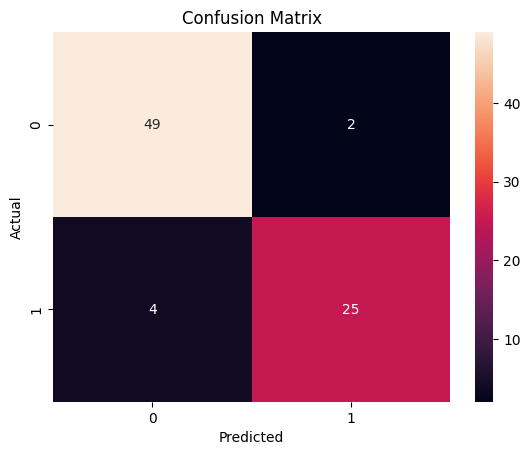

In [ ]:
# Plot the Confusion Matrix
sns.heatmap(confusion_matrix, annot=True)
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows that the model performed well

49 values were correctly predicted as class 0 (True Negatives)

25 values were correctly predicted as class 1 (True Positives)

2 values were incorrectly predicted as class 1 when they were actually 0 (False Positives)

4 values were incorrectly predicted as class 0 when they were actually 1 (False Negatives)


In [ ]:
# Accuracy Score
print('Accuracy: ', metrics.accuracy_score(y_test, y_pred))

Accuracy:  0.925


In [ ]:
# Predicted Values
y_pred = logistic_regression.predict(X_test)
y_pred

array([1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1])

In [ ]:
# Intercept and Coefficients
print('Intercept: \n', logistic_regression.intercept_)
print('Coefficients: \n', logistic_regression.coef_)

Intercept: 
 [-12.72380494]
Coefficients: 
 [[1.71494718e-01 1.10101720e-05 1.44152848e-01 3.99390370e-01]]


In [ ]:
# Model Summmary
import statsmodels.api as sm

# Re-initialize X to ensure no duplicate 'const' column and to remove problematic features
X_sm = df[["Age", "EstimatedSalary", "Time_Spent", "Num_of_children"]]
y_sm = df['Purchased']

X_sm = sm.add_constant(X_sm)
logit_model = sm.Logit(y_sm, X_sm).fit()
logit_model.summary()

# y = -13.84 + 0.188(Age) + 0.00001882(EstimatedSalary) + 0.143(Time_Spent) + 0.345(Num_of_Children)
# Num_of_children not statistically significant

Optimization terminated successfully.
         Current function value: 0.210711
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              Purchased   No. Observations:                  400
Model:                          Logit   Df Residuals:                      395
Method:                           MLE   Df Model:                            4
Date:                Thu, 28 May 2026   Pseudo R-squ.:                  0.6768
Time:                        13:49:37   Log-Likelihood:                -84.284
converged:                       True   LL-Null:                       -260.79
Covariance Type:            nonrobust   LLR p-value:                 3.938e-75
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -13.8471      1.568     -8.832      0.000     -16.920     -10.774
Age                 0.1875      0.028      6.679      0.000       0.133       0.243
EstimatedSalary  1.882e-05   7.13e-06      2.641      0.008    4.85e-06    3.28e-05
Time_Spent          0.1434      0.021      6.773      0.000       0.102       0.185
Num_of_children     0.3445      0.221      1.559      0.119      -0.089       0.778
===================================================================================
"""

### RANDOM FOREST

In [ ]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print(f"Categorical columns: {list(categorical_cols)}")
print(f"Numerical columns: {list(numerical_cols)}")

Categorical columns: []
Numerical columns: ['Age', 'EstimatedSalary', 'Time_Spent', 'Num_of_children']


In [ ]:
# Apply one-hot encoding to categorical features
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Shape of X after one-hot encoding: {X_encoded.shape}")
display(X_encoded.head())

Shape of X after one-hot encoding: (400, 4)


,Age,EstimatedSalary,Time_Spent,Num_of_children
0,30,15000.0,15.0,2.0
1,26,15000.0,10.0,0.0
2,26,15000.0,13.0,1.0
3,31,15000.0,16.0,0.0
4,21,16000.0,9.0,1.0


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=0)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (320, 4)
X_test shape: (80, 4)
y_train shape: (320,)
y_test shape: (80,)


In [ ]:
# Initialize and train the RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [ ]:
# Predict purchase outcomes on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Evaluation:
Accuracy: 0.9250

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        53
           1       0.86      0.93      0.89        27

    accuracy                           0.93        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80



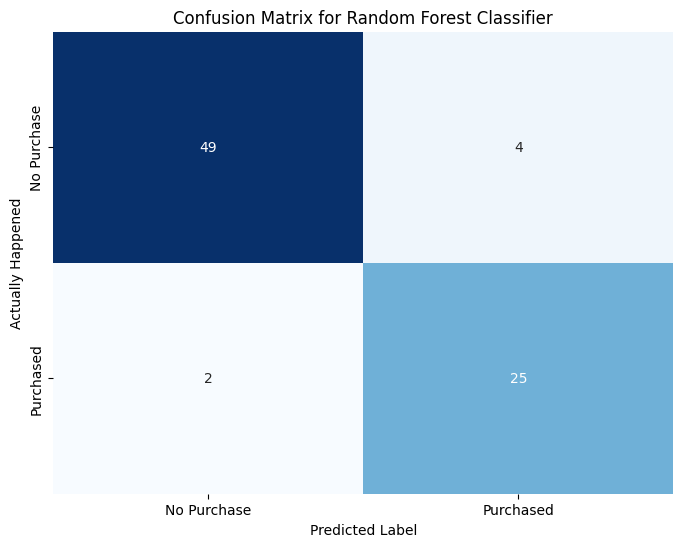

In [ ]:
# Create the confusion matrix using the predictions from the Random Forest model
cm = metrics.confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Purchase', 'Purchased'],
            yticklabels=['No Purchase', 'Purchased'])
plt.xlabel('Predicted Label')
plt.ylabel('Actually Happened')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()

The 49 customers were correctly predicted as No Purchase (True Negatives)

25 customers were correctly predicted as Purchased (True Positives)

4 customers were predicted as Purchased when they actually did not purchase (False Positives)

2 customers were predicted as No Purchase when they actually purchased (False Negatives)

## Model Comparison: Logistic Regression vs Random Forest

In [ ]:
## Model Comparison: Logistic Regression vs Random Forest

In [ ]:
# Clean column names
df.columns = df.columns.str.strip()

# Define target
y = df["Purchased"]

# Define features
X = df.drop(columns=["Purchased"], errors="ignore")

# Remove duplicated / unnecessary columns if they exist
X = X.drop(columns=["Purch_Attention_Numerical"], errors="ignore")

In [ ]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: []
Numerical columns: ['Gender', 'Age', 'EstimatedSalary', 'Education_Livel', 'Region', 'Employment_type', 'Time_Spent', 'Num_of_children', 'Purch_Attention', 'Gender_Numerical']


In [ ]:
# For Logistic Regression
numeric_transformer_log = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# For Random Forest
numeric_transformer_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_log = ColumnTransformer([
    ("num", numeric_transformer_log, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

preprocessor_rf = ColumnTransformer([
    ("num", numeric_transformer_rf, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

log_model = Pipeline([
    ("preprocessor", preprocessor_log),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

rf_model = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    })

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Logistic Regression
Confusion Matrix:
[[46  5]
 [ 0 29]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        51
           1       0.85      1.00      0.92        29

    accuracy                           0.94        80
   macro avg       0.93      0.95      0.93        80
weighted avg       0.95      0.94      0.94        80


Random Forest
Confusion Matrix:
[[47  4]
 [ 0 29]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        51
           1       0.88      1.00      0.94        29

    accuracy                           0.95        80
   macro avg       0.94      0.96      0.95        80
weighted avg       0.96      0.95      0.95        80



In [ ]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Logistic Regression,0.9375,0.852941,1.0,0.920635,0.999324
1,Random Forest,0.9500,0.878788,1.0,0.935484,1.000000


In [ ]:
X_without_attention = X.drop(columns=["Purch_Attention"], errors="ignore")

In [ ]:
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="roc_auc"
    )

    cv_results.append({
        "Model": name,
        "Mean ROC AUC": scores.mean(),
        "Std ROC AUC": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Model,Mean ROC AUC,Std ROC AUC
0,Logistic Regression,0.996755,0.006491
1,Random Forest,0.997431,0.005139


Cross-validation evaluates the reliability and performance of the machine learning models across multiple data splits.
Both Logistic Regression and Random Forest achieved high ROC AUC scores above 0.99

This indicates excellent predictive accuracy in distinguishing purchasing and non-purchasing customers

Random Forest performed slightly better and showed greater consistency due to its lower standard deviation